In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score


In [ ]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')
TCAV_ROOT = PROJECT_ROOT / 'resnet_293' / 'tcav' / 'captum_tcav' / 'asvspoof5'
OUTPUT_SUBDIR = 'subset_20spk_20utts_per_spk_one_logistic_head'
OUTPUT_DIR = TCAV_ROOT / 'output' / OUTPUT_SUBDIR

INPUT_CSV = OUTPUT_DIR / 'merged_tcav_sign_count_speaker_level.csv'

TARGET_SYSTEM = 'A02'
EXCLUDE_A12 = True
LOGREG_MAX_ITER = 2000
LOGREG_C = 1.0
RANDOM_SEED = 42

print('INPUT_CSV =', INPUT_CSV)
print('Exists =', INPUT_CSV.exists())
print('TARGET_SYSTEM =', TARGET_SYSTEM)


INPUT_CSV = /home/SpeakerRec/BioVoice/resnet_293/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/merged_tcav_sign_count_speaker_level.csv
Exists = True
TARGET_SYSTEM = A07


In [3]:
# ===== Load data and filter to target system =====
df = pd.read_csv(INPUT_CSV)
if EXCLUDE_A12:
    df = df[df['system_id'] != 'A12'].copy()

meta_cols = ['speaker_id', 'split', 'source_partition', 'system_id', 'target_class', 'binary_label']
feature_cols = [c for c in df.columns if c not in meta_cols and c != 'n_utterances']

sys_df = df[df['system_id'] == TARGET_SYSTEM].copy().reset_index(drop=True)
y = sys_df['binary_label'].to_numpy(dtype=int)

print(f'System {TARGET_SYSTEM}: {len(sys_df)} rows')
print(f'  bonafide (0): {(y == 0).sum()}')
print(f'  spoof    (1): {(y == 1).sum()}')
print(f'  Concepts: {len(feature_cols)}')
print(f'  Concept names: {feature_cols}')
display(sys_df.head())


System A07: 40 rows
  bonafide (0): 20
  spoof    (1): 20
  Concepts: 12
  Concept names: ['long_constant_thick', 'long_dropping_flat_thick', 'long_dropping_steep_thick', 'long_dropping_steep_thin', 'long_rising_flat_thick', 'long_rising_steep_thick', 'long_rising_steep_thin', 'short_constant_thick', 'short_dropping_steep_thick', 'short_dropping_steep_thin', 'short_rising_steep_thick', 'short_rising_steep_thin']


,speaker_id,split,source_partition,system_id,target_class,binary_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin,n_utterances
0,T_0346,test,train,A07,bonafide,0,0.35,0.30,0.40,0.35,0.35,0.45,0.35,0.60,0.45,0.50,0.40,0.40,20
1,T_0380,test,train,A07,bonafide,0,0.25,0.30,0.20,0.10,0.25,0.20,0.10,0.20,0.30,0.15,0.30,0.30,20
2,T_0571,test,train,A07,bonafide,0,0.75,0.55,0.70,0.55,0.60,0.75,0.65,0.65,0.65,0.70,0.70,0.65,20
3,T_0877,test,train,A07,bonafide,0,0.10,0.10,0.10,0.00,0.20,0.10,0.05,0.15,0.10,0.05,0.15,0.10,20
4,T_1860,test,train,A07,bonafide,0,0.40,0.30,0.15,0.05,0.15,0.30,0.25,0.45,0.35,0.20,0.55,0.10,20


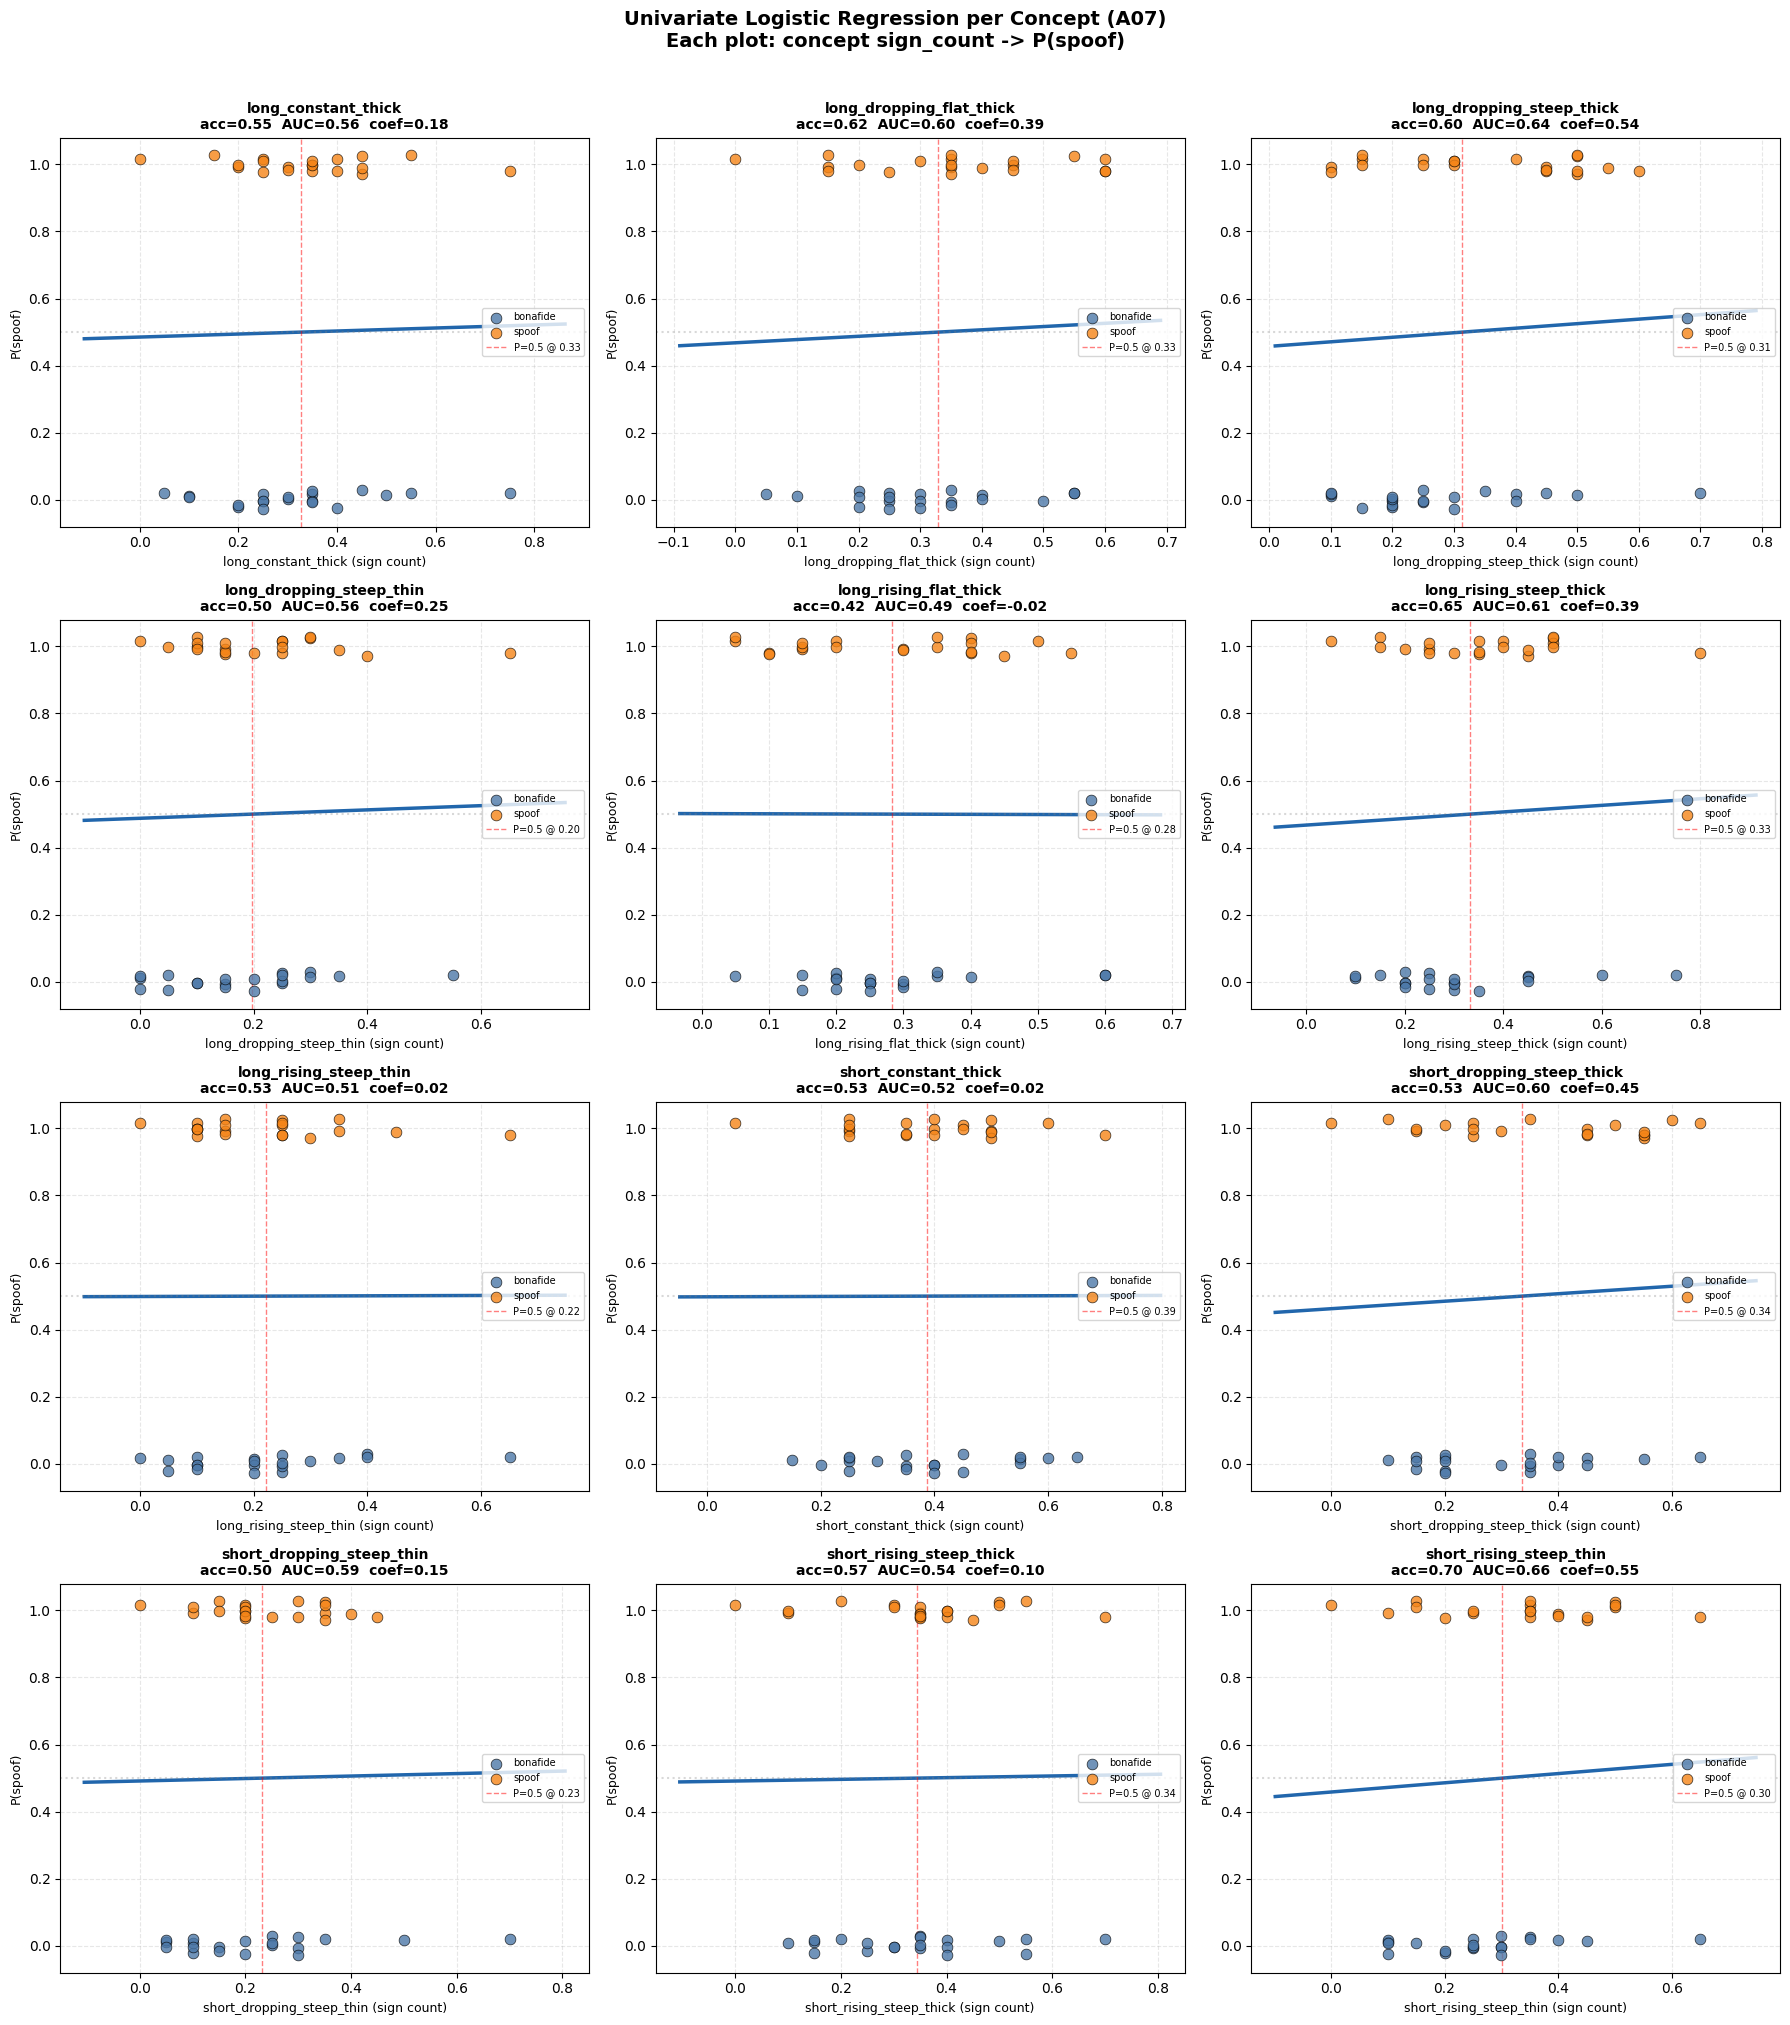

In [4]:
# ===== Fit univariate logistic regression per concept and plot =====

n_concepts = len(feature_cols)
ncols = 3
nrows = (n_concepts + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

results = []

for i, concept in enumerate(feature_cols):
    ax = axes[i]
    x_raw = sys_df[concept].to_numpy(dtype=float)

    # Fit univariate logistic regression
    X_1d = x_raw.reshape(-1, 1)
    uni_clf = LogisticRegression(
        max_iter=LOGREG_MAX_ITER, C=LOGREG_C,
        random_state=RANDOM_SEED, solver='lbfgs',
    )
    uni_clf.fit(X_1d, y)

    # Predictions and metrics
    p_spoof = uni_clf.predict_proba(X_1d)[:, 1]
    yhat = (p_spoof >= 0.5).astype(int)
    acc = accuracy_score(y, yhat)
    auc = roc_auc_score(y, p_spoof) if len(np.unique(y)) == 2 else float('nan')

    coef = float(uni_clf.coef_[0, 0])
    intercept = float(uni_clf.intercept_[0])

    results.append({
        'concept': concept,
        'coef': round(coef, 4),
        'intercept': round(intercept, 4),
        'accuracy': round(acc, 4),
        'auc': round(auc, 4),
    })

    # ---- Plot sigmoid curve ----
    x_min, x_max = x_raw.min(), x_raw.max()
    margin = max(0.05, (x_max - x_min) * 0.15)
    x_grid = np.linspace(x_min - margin, x_max + margin, 300)
    logit_grid = coef * x_grid + intercept
    p_grid = 1.0 / (1.0 + np.exp(-logit_grid))

    ax.plot(x_grid, p_grid, color='#2166ac', linewidth=2.5, zorder=2)

    # ---- Scatter data points ----
    bonafide_mask = y == 0
    spoof_mask = y == 1

    # Small jitter on y so dots don't overlap perfectly
    jitter_rng = np.random.default_rng(RANDOM_SEED)
    jitter_b = jitter_rng.uniform(-0.03, 0.03, size=bonafide_mask.sum())
    jitter_s = jitter_rng.uniform(-0.03, 0.03, size=spoof_mask.sum())

    ax.scatter(x_raw[bonafide_mask], 0.0 + jitter_b,
               color='#4C78A8', edgecolors='black', linewidths=0.5,
               s=60, alpha=0.8, zorder=3, label='bonafide')
    ax.scatter(x_raw[spoof_mask], 1.0 + jitter_s,
               color='#F58518', edgecolors='black', linewidths=0.5,
               s=60, alpha=0.8, zorder=3, label='spoof')

    # Decision boundary (P=0.5 line)
    if coef != 0:
        x_decision = -intercept / coef
        if x_min - margin <= x_decision <= x_max + margin:
            ax.axvline(x=x_decision, color='red', linestyle='--', alpha=0.5,
                       linewidth=1, label=f'P=0.5 @ {x_decision:.2f}')

    ax.axhline(y=0.5, color='grey', linestyle=':', alpha=0.3)
    ax.set_ylim(-0.08, 1.08)
    ax.set_xlabel(f'{concept} (sign count)', fontsize=9)
    ax.set_ylabel('P(spoof)', fontsize=9)
    ax.set_title(f'{concept}\nacc={acc:.2f}  AUC={auc:.2f}  coef={coef:.2f}',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='center right')
    ax.grid(True, linestyle='--', alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Univariate Logistic Regression per Concept ({TARGET_SYSTEM})\n'
             f'Each plot: concept sign_count -> P(spoof)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [5]:
# ===== Summary table =====
results_df = pd.DataFrame(results).sort_values('auc', ascending=False).reset_index(drop=True)
print(f'Univariate logistic regression results for {TARGET_SYSTEM}:')
display(results_df)

print()
print('Interpretation:')
print('  - Positive coef: higher sign_count -> more likely spoof')
print('  - Negative coef: higher sign_count -> more likely bonafide')
print('  - AUC close to 1.0: concept strongly separates spoof from bonafide')
print('  - AUC close to 0.5: concept has no discriminative power')


Univariate logistic regression results for A07:


,concept,coef,intercept,accuracy,auc
0,short_rising_steep_thin,0.5531,-0.1666,0.700,0.6587
1,long_dropping_steep_thick,0.5423,-0.1701,0.600,0.6350
2,long_rising_steep_thick,0.3940,-0.1310,0.650,0.6150
3,short_dropping_steep_thick,0.4484,-0.1508,0.525,0.6050
4,long_dropping_flat_thick,0.3882,-0.1276,0.625,0.6013
5,short_dropping_steep_thin,0.1473,-0.0341,0.500,0.5887
6,long_constant_thick,0.1802,-0.0588,0.550,0.5563
7,long_dropping_steep_thin,0.2514,-0.0496,0.500,0.5550
8,short_rising_steep_thick,0.1008,-0.0346,0.575,0.5437
9,short_constant_thick,0.0209,-0.0081,0.525,0.5162



Interpretation:
  - Positive coef: higher sign_count -> more likely spoof
  - Negative coef: higher sign_count -> more likely bonafide
  - AUC close to 1.0: concept strongly separates spoof from bonafide
  - AUC close to 0.5: concept has no discriminative power
